<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding How The Data Is Distributed**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform Exploratory Data Analysis (EDA). You will examine the structure of the data, visualize key variables, and analyze trends related to developer experience, tools, job satisfaction, and other important aspects.


## Objectives


In this lab you will perform the following:


- Understand the structure of the dataset.

- Perform summary statistics and data visualization.

- Identify trends in developer experience, tools, job satisfaction, and other key variables.


### Install the required libraries


In [ ]:
!pip install pandas
!pip install matplotlib
!pip install seaborn


### Step 1: Import Libraries and Load Data


- Import the `pandas`, `matplotlib.pyplot`, and `seaborn` libraries.


- You will begin with loading the dataset. You can use the pyfetch method if working on JupyterLite. Otherwise, you can use pandas' read_csv() function directly on their local machines or cloud environments.


In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Stack Overflow survey dataset
data_url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv'
df = pd.read_csv(data_url)

# Display the first few rows of the dataset
df.head()


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Step 2: Examine the Structure of the Data


- Display the column names, data types, and summary information to understand the data structure.

- Objective: Gain insights into the dataset's shape and available variables.


In [2]:
df_save = df.copy()

In [3]:
## Write your code here
df.columns
df.dtypes
df.describe()
df.shape

(65437, 114)

### Step 3: Handle Missing Data


- Identify missing values in the dataset.

- Impute or remove missing values as necessary to ensure data completeness.



In [4]:
#columns having 0 missing values
for col in df.columns:
    if(df[col].isnull().sum() == 0):
        print(f"{col} has {df[col].isnull().sum()} missing values.")

ResponseId has 0 missing values.
MainBranch has 0 missing values.
Age has 0 missing values.
Employment has 0 missing values.
Check has 0 missing values.


In [5]:
#Notable columns
notable_cols = ['ResponseId', 'MainBranch', 'Employment', 'Country', 'Age', 'YearsCodePro', 'LanguageHaveWorkedWith', 'DevType', 'EdLevel', 'RemoteWork', 'CompTotal', 'JobSat']
for col in notable_cols:
    if df[col].count() < df.shape[0]:
        print(col,"\t",df.shape[0]-df[col].count())

Country 	 6507
YearsCodePro 	 13827
LanguageHaveWorkedWith 	 5692
DevType 	 5992
EdLevel 	 4653
RemoteWork 	 10631
CompTotal 	 31697
JobSat 	 36311


In [6]:
## Write your code here
# 'Unknown': columns where imputation can distort statistics
df['Country'] = df['Country'].fillna('Unknown')
df['LanguageHaveWorkedWith'] = df['LanguageHaveWorkedWith'].fillna('Unknown')
df['DevType'] = df['DevType'].fillna('Unknown')
df['RemoteWork'] = df['RemoteWork'].fillna('Unknown')

In [ ]:
#df['CompTotal'] = df['CompTotal'].fillna(df['CompTotal'].median()) # not a good policy
#Check NAN for each country
#print("Number of NAN in 'CompTotal' column: ",df['CompTotal'].isna().sum())
#df['CompTotal'].isna().groupby(df['Country']).sum().sort_values()
#df.groupby('Country')['CompTotal'].apply(lambda x: x.isna().sum())
#df.groupby('Country')['CompTotal'].size() - df.groupby('Country')['CompTotal'].count()

#first, fill NAN with the median of its country
df['CompTotal'] = df.groupby('Country')['CompTotal'].transform(lambda x: x.fillna(x.median()))

#cmptl = cmptl.fillna(df['CompTotal'].median()) # not a good policy

Number of NAN in 'CompTotal' column:  6534


c:\Users\IMST\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\IMST\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\IMST\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\IMST\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\IMST\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1231: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=

0        False
1        False
2        False
3        False
4        False
         ...  
65432     True
65433     True
65434     True
65435    False
65436     True
Name: Nan Country, Length: 65437, dtype: bool

In [7]:
print("Number of NAN in 'CompTotal' column: ",df['CompTotal'].isna().sum())
#df['Nan Country'] = df.groupby('Country')['CompTotal'].transform('median').isna()
#df['Nan Country']
median_isna = df.groupby('Country')['CompTotal'].median().isna()
nan_cl = median_isna[median_isna].index.tolist()
nan_cl
# df['Nan Country'] = df['Country'].map(median_isna)
# df['Nan Country'].count()

Number of NAN in 'CompTotal' column:  31697


['Bahamas',
 'Belize',
 'Djibouti',
 'Dominica',
 'Equatorial Guinea',
 'Guinea',
 'Guinea-Bissau',
 'Liberia',
 'Micronesia, Federated States of...',
 'Nauru',
 'North Korea',
 'Papua New Guinea',
 'Saint Kitts and Nevis',
 'San Marino',
 'Solomon Islands',
 'Unknown']

In [8]:
df['YearsCodePro'] = df['YearsCodePro'].replace({'Less than 1 year':'0','More than 50 years':'51'}).astype(float)
df['YearsCodePro'] = df['YearsCodePro'].fillna(df['YearsCodePro'].mode()[0])
df['YearsCodePro'].unique()

array([ 2., 17., 27.,  7., 11., 25., 12., 10.,  3.,  0., 18., 37., 15.,
       20.,  6., 16.,  8., 14.,  4., 45.,  1., 24., 29.,  5., 30., 26.,
        9., 33., 13., 35., 23., 22., 31., 19., 21., 28., 34., 32., 40.,
       50., 39., 44., 42., 41., 36., 38., 51., 43., 47., 48., 46., 49.])

In [9]:
df['EdLevel'] = df['EdLevel'].fillna(df['EdLevel'].mode()[0])
df['JobSat'] = df['JobSat'].fillna(df['JobSat'].mode()[0])

### Step 4: Analyze Key Columns


- Examine key columns such as `Employment`, `JobSat` (Job Satisfaction), and `YearsCodePro` (Professional Coding Experience).

- **Instruction**: Calculate the value counts for each column to understand the distribution of responses.



In [10]:
## Write your code here
df['Employment'].unique()
df['Employment'].str.split(';').explode().value_counts()

Employment
Employed, full-time                                     45162
Independent contractor, freelancer, or self-employed    10726
Student, full-time                                       8626
Employed, part-time                                      4145
Not employed, but looking for work                       3954
Student, part-time                                       2656
Not employed, and not looking for work                   1203
Retired                                                   681
I prefer not to say                                       546
Name: count, dtype: int64

In [11]:
df['JobSat'].unique()
df['JobSat'].value_counts()

JobSat
8.0     43820
7.0      6379
6.0      3751
9.0      3626
10.0     2251
5.0      1956
3.0      1165
4.0      1130
2.0       772
0.0       311
1.0       276
Name: count, dtype: int64

In [53]:
df_save['YearsCodePro'].unique()
df_save['YearsCodePro'].value_counts()

YearsCodePro
2                     4168
3                     4093
5                     3526
10                    3251
4                     3215
Less than 1 year      2856
6                     2843
1                     2639
8                     2549
7                     2517
12                    1777
15                    1635
20                    1549
9                     1493
11                    1312
13                    1127
14                    1082
25                     998
16                     946
18                     867
17                     814
30                     689
24                     632
19                     516
22                     492
23                     448
26                     426
27                     380
21                     380
28                     342
35                     285
29                     196
40                     194
32                     194
34                     169
38                     134
33             

### Step 5: Visualize Job Satisfaction (Focus on JobSat)


- Create a pie chart or KDE plot to visualize the distribution of `JobSat`.

- Provide an interpretation of the plot, highlighting key trends in job satisfaction.


<Axes: xlabel='JobSat', ylabel='Density'>

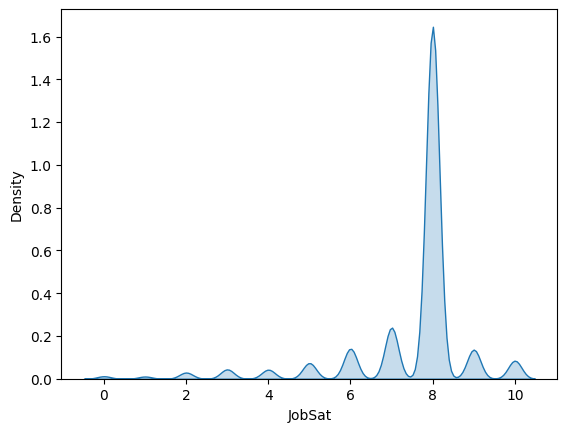

In [12]:
## Write your code here
sns.kdeplot(df['JobSat'], fill=True)

### My interpretation
1. Job satisfaction levels are generally very high.
2. The summation of low level(below level 6) job satisfacion is smaller than 10%.
3. The mean of JobSat is bigger than 7.5.

### Step 6: Programming Languages Analysis


- Compare the frequency of programming languages in `LanguageHaveWorkedWith` and `LanguageWantToWorkWith`.
  
- Visualize the overlap or differences using a Venn diagram or a grouped bar chart.


In [13]:
cur_lang = df['LanguageHaveWorkedWith'].str.split(';').explode().value_counts()
next_lang = df['LanguageWantToWorkWith'].str.split(';').explode().value_counts()
common_lang = list(set(cur_lang.index) & set(next_lang.index))
print(len(cur_lang),len(next_lang),len(common_lang))


50 49 49


In [16]:
columns = [ 'Language', 'CurLangFreq', 'NextLangFreq']
rows = []
for l in common_lang:
    rows.append({columns[0]:l,columns[1]:cur_lang[l],columns[2]:next_lang[l]})
rows
df_lang = pd.DataFrame(rows, columns=columns)
df_lang

,Language,CurLangFreq,NextLangFreq
0,C++,13827,10873
1,Rust,7559,17232
2,MicroPython,942,1039
3,Swift,2829,3877
4,Zig,667,3688
5,Ruby,3147,2774
6,PowerShell,8328,4287
7,Apex,502,389
8,SQL,30682,22400
9,C#,16318,12921


<Axes: >

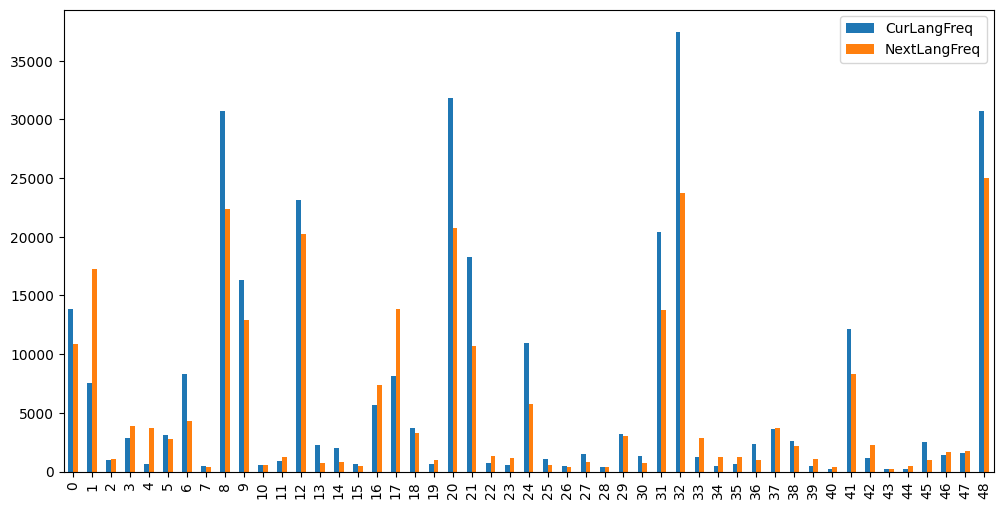

In [18]:
## Write your code here
#df_lang
df_lang.plot(kind='bar', figsize=(12,6))

### Step 7: Analyze Remote Work Trends


- Visualize the distribution of RemoteWork by region using a grouped bar chart or heatmap.


In [ ]:
## Write your code here
import country_converter as coco

cc = coco.CountryConverter()
country_u = df['Country'].unique()
continent_l = cc.convert(names=country_u, to='continent')
country_continent = pd.Series(data=continent_l,index=country_u)
df['Continent'] = df['Country'].map(country_continent)
df[df['Continent']=='not found']['Country']

Nomadic not found in regex
Unknown not found in regex


1634     Nomadic
2464     Nomadic
6039     Nomadic
6886     Nomadic
6985     Nomadic
          ...   
65430    Unknown
65432    Unknown
65433    Unknown
65434    Unknown
65436    Unknown
Name: Country, Length: 6550, dtype: object

<Axes: xlabel='Continent'>

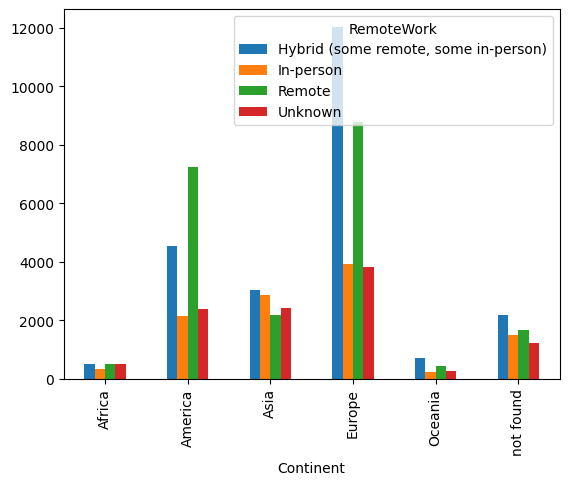

In [32]:
cg_remotework = df.groupby('Continent')['RemoteWork'].value_counts(sort=False)
cg_remotework = cg_remotework.unstack()
cg_remotework.plot(kind='bar')

### Step 8: Correlation between Job Satisfaction and Experience


- Analyze the correlation between overall job satisfaction (`JobSat`) and `YearsCodePro`.
  
- Calculate the Pearson or Spearman correlation coefficient.


The Pearson Correlation Coefficient is 0.006203511925239597  with a P-value of P = 0.11253890890126149
                JobSat  YearsCodePro
JobSat        1.000000      0.006204
YearsCodePro  0.006204      1.000000


<Axes: xlabel='YearsCodePro', ylabel='JobSat'>

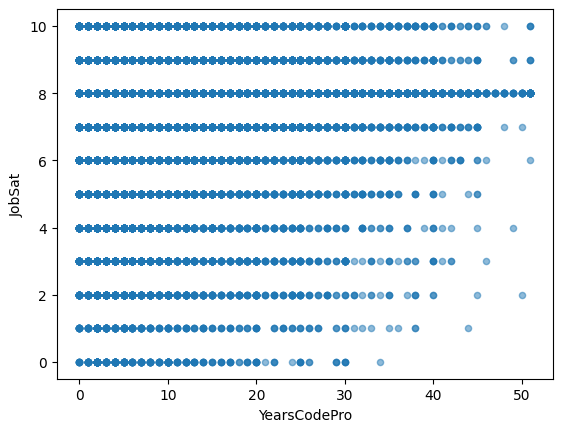

In [33]:
## Write your code here
df.loc[df['YearsCodePro'] == 'Less than 1 year', 'YearsCodePro'] = 0
df.loc[df['YearsCodePro'] == 'More than 50 years', 'YearsCodePro'] = 51
df['YearsCodePro'] = df['YearsCodePro'].astype(float)
from scipy import stats
pearson_coef, p_value = stats.pearsonr(df['JobSat'], df['YearsCodePro'])
print("The Pearson Correlation Coefficient is", pearson_coef, " with a P-value of P =", p_value)
corr_v = df[['JobSat','YearsCodePro']].corr()
print(corr_v)
df[['JobSat','YearsCodePro']].plot(kind='scatter', x='YearsCodePro', y='JobSat', alpha=0.5)

### Step 9: Cross-tabulation Analysis (Employment vs. Education Level)


- Analyze the relationship between employment status (`Employment`) and education level (`EdLevel`).

- **Instruction**: Create a cross-tabulation using `pd.crosstab()` and visualize it with a stacked bar plot if possible.


In [34]:
df['Employment'].value_counts()
df['EdLevel'].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          29595
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       15557
Some college/university study without earning a degree                                 7651
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     5793
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2970
Associate degree (A.A., A.S., etc.)                                                    1793
Primary/elementary school                                                              1146
Something else                                                                          932
Name: count, dtype: int64

In [49]:
## Write your code here
import numpy as np
conditions = [
    df['Employment'].str.startswith("Employed", na=False),
    df['Employment'].str.startswith("Not employed", na=False),
    df['Employment'].str.startswith("Independent", na=False)
]
choices = ["Employed", "NotEmployed", "Independent"]
df['EmpCategory'] = np.select(conditions, choices, default="Student")
df['EmpCategory'].value_counts()

EmpCategory
Employed       46436
Student         9682
Independent     5574
NotEmployed     3745
Name: count, dtype: int64

<Axes: xlabel='EmpCategory'>

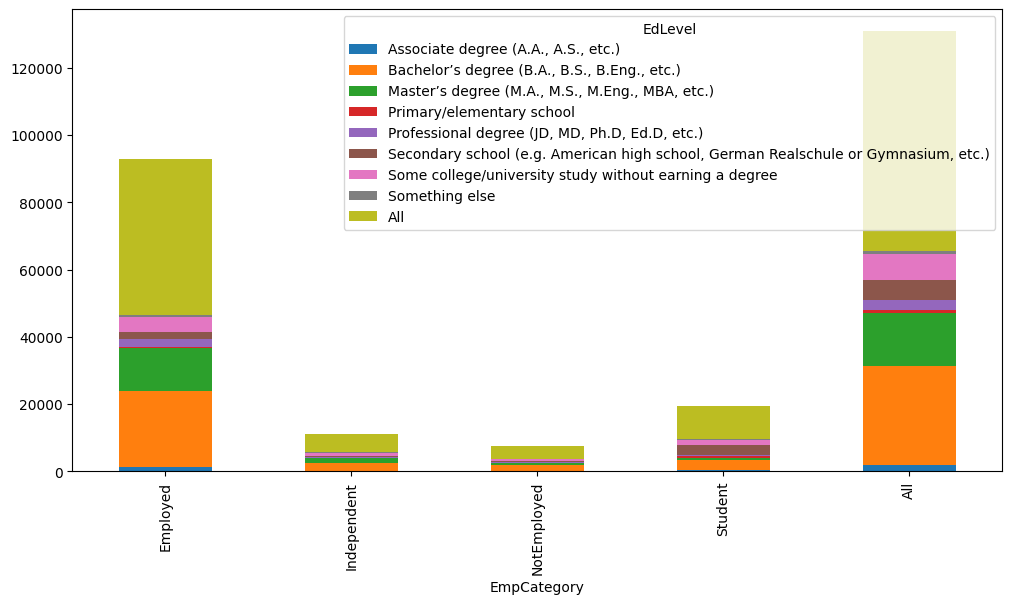

In [50]:
emp_edu = pd.crosstab(df['EmpCategory'], df['EdLevel'], margins=True)
emp_edu.plot(kind='bar', figsize=(12,6),stacked=True)

### Step 10: Export Cleaned Data


- Save the cleaned dataset to a new CSV file for further use or sharing.


In [51]:
## Write your code here
df.to_csv('survey-data.csv')

### Summary:


In this lab, you practiced key skills in exploratory data analysis, including:


- Examining the structure and content of the Stack Overflow survey dataset to understand its variables and data types.

- Identifying and addressing missing data to ensure the dataset's quality and completeness.

- Summarizing and visualizing key variables such as job satisfaction, programming languages, and remote work trends.

- Analyzing relationships in the data using techniques like:
    - Comparing programming languages respondents have worked with versus those they want to work with.
      
    - Exploring remote work preferences by region.

- Investigating correlations between professional coding experience and job satisfaction.

- Performing cross-tabulations to analyze relationships between employment status and education levels.


## Authors:
Ayushi Jain


### Other Contributors:
Rav Ahuja
Lakshmi Holla
Malika


Copyright © IBM Corporation. All rights reserved.
